In [21]:
import pandas as pd
import matplotlib.pyplot as plt 
from benefits_defns import *


In [7]:
accuracy_df = pd.read_excel('../../exports/highlighted_job_postings_2_exploded.xlsx')

In [24]:
# set font size as 16
plt.rcParams.update({'font.size': 16})

In [8]:
accuracy_df

,Benefit,ID,AI Role,Description,Keywords Found,Accurate?,Key Phrases
0,CAREER_DEV,a439e2c228bcaf0319973b478bbda4dbc73031c0,False,Back to search\nMSC\nMarket Insights Program M...,growth opportunities,N,NaN
1,CAREER_DEV,a439e2c228bcaf0319973b478bbda4dbc73031c0,False,Back to search\nMSC\nMarket Insights Program M...,tuition reimbursement,Y,NaN
2,CAREER_DEV,a439e2c228bcaf0319973b478bbda4dbc73031c0,False,Back to search\nMSC\nMarket Insights Program M...,professional development,Y,NaN
3,CAREER_DEV,ebe1919c08842875f5d76042d335fe3ab8d197a2,True,Data Scientist\n\nSpotXchange\n\nPosted Under:...,education assistance,Y,NaN
4,CAREER_DEV,b9cedb938a1137556dd2b10cbc90727c5f5514e8,False,Glassdoor will not work properly unless browse...,Tuition reimbursement,Y,NaN
...,...,...,...,...,...,...,...
406,CULTURE,bd887deb6368e8d7d7a59664124bdb279c331eb3,True,Senior Data Visualization Designer\n\nJob Fami...,collaborative environment,Y,complex and collaborative environment
407,CULTURE,bd887deb6368e8d7d7a59664124bdb279c331eb3,True,Senior Data Visualization Designer\n\nJob Fami...,Diversity and Inclusion,Y,NaN
408,CULTURE,2333e601961a7eb6fc99cfdb025afb5b1ff47969,False,"Industrial Engineer\nLocation Hebron, Kentucky...",inclusive environment,Y,NaN
409,CULTURE,569618ca85775dfecf561a52ef2b6f0425c927dc,True,JOB DETAILS\n\nJob Details\nOracle GTM Strateg...,inclusive culture,Y,NaN


In [9]:
accuracy_df['is_accurate'] = accuracy_df['Accurate?'].map({'Y': True, 'N': False})

In [10]:
accuracy_df['Keywords Found'] = accuracy_df['Keywords Found'].str.lower()

In [12]:
keyword_accuracy = accuracy_df.groupby(['Benefit', 'Keywords Found']).agg(
    total_matches = ('is_accurate', 'size'), 
    total_accurate = ('is_accurate', 'sum'))


In [13]:
keyword_accuracy

total_matches  total_accurate
Benefit          Keywords Found                                          
CAREER_DEV       career advancement                     2               2
                 career growth                          4               4
                 education assistance                   2               2
                 education reimbursement                1               1
                 growth opportunities                   5               3
                 leadership development                 4               2
                 mentorship                             3               0
                 personal development                   2               2
                 professional development              15              13
                 training programs                      3               1
                 tuition assistance                     6               6
                 tuition reimbursement                 30              29
CULTURE          collaborative environment              7               7
                 diverse team                           9               9
                 diversity and inclusion               21              20
                 inclusive culture                      7               7
                 inclusive environment                 11              11
                 team culture                           2               1
                 values-driven                          1               1
FAMILY           childcare                             12               5
                 family support                         1               1
                 parental leave                        52              52
                 paternity leave                        4               4
HEALTH_WELLBEING gym membership                         2               2
                 health benefits                       20              18
                 mental health support                  2               2
                 wellness program                       7               7
                 wellness programs                     24              24
RECOGNITION      employee of the month                  2               2
                 employee recognition                  10               7
                 peer recognition                       4               4
                 recognition program                   34              34
                 service awards                         3               3
WLB              generous time off                      3               3
                 holiday pay                            3               3
                 paid holidays                         17              17
                 paid time off                         44              44
                 paid vacation                          8               8
                 pto                                   15              15
                 work-life balance                      5               5
                 work/life balance                      4               4

In [14]:
keyword_accuracy['accuracy_percentage'] = (keyword_accuracy['total_accurate'] / keyword_accuracy['total_matches']) * 100

In [15]:
keyword_accuracy['total_inaccurate'] = keyword_accuracy['total_matches'] - keyword_accuracy['total_accurate']

In [16]:
# move Keywords Found out of index
keyword_accuracy.reset_index(inplace=True)

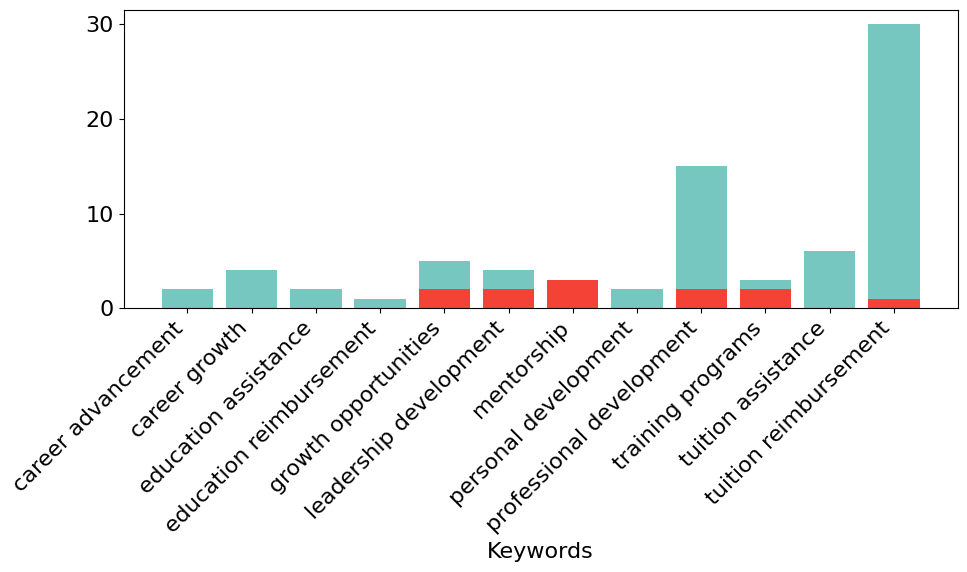

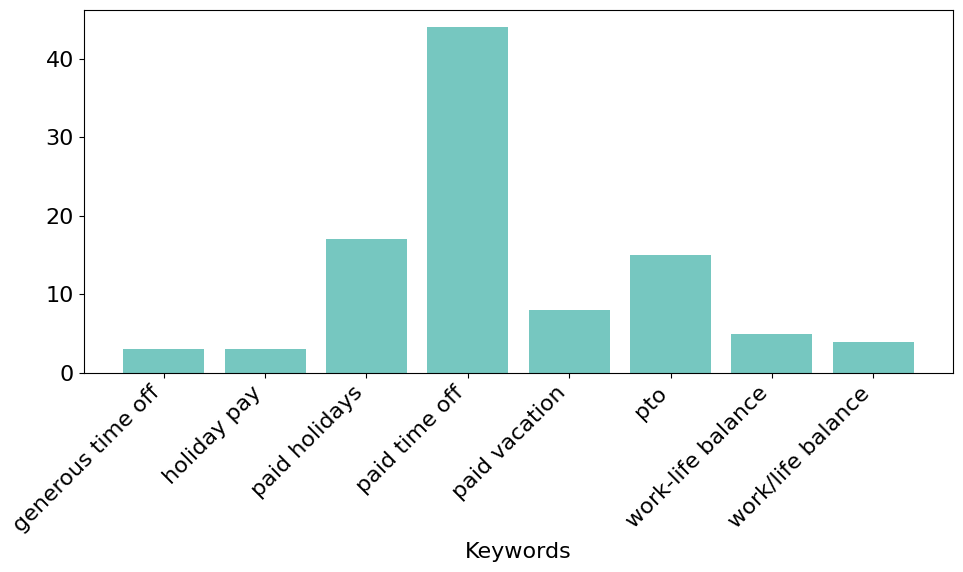

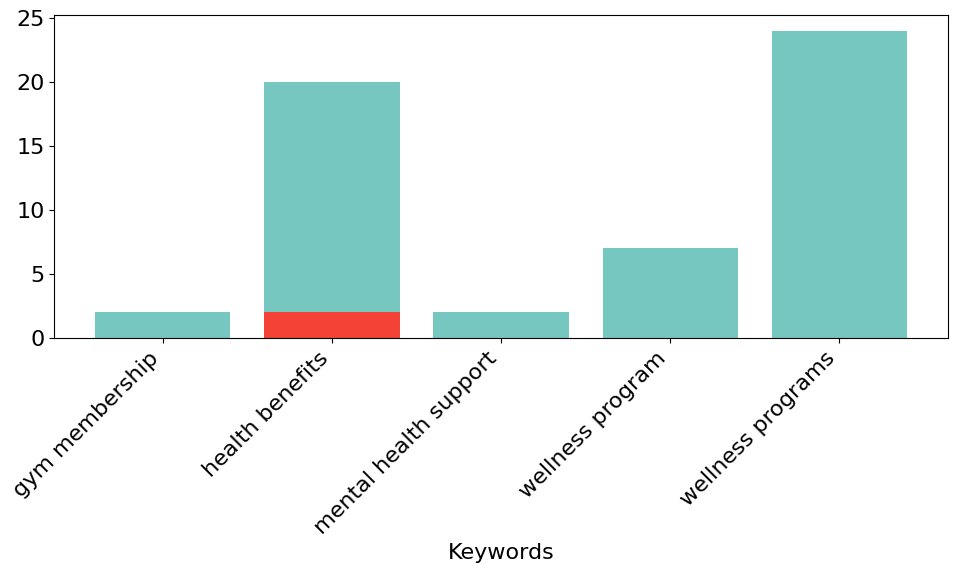

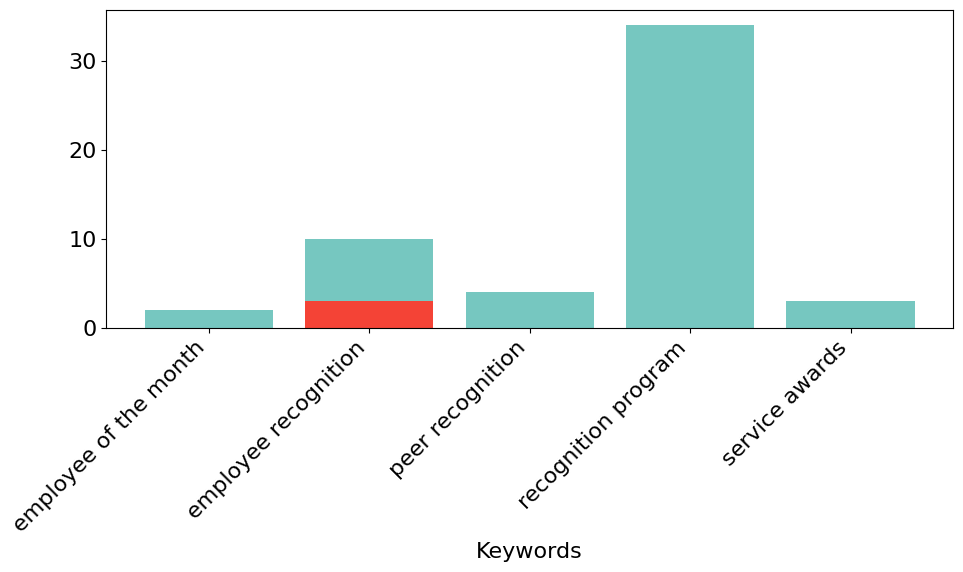

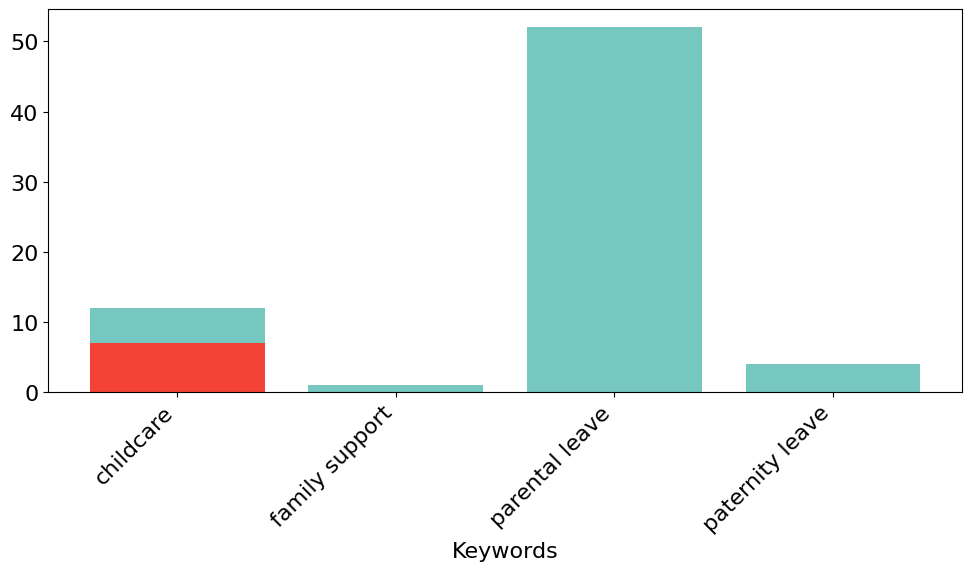

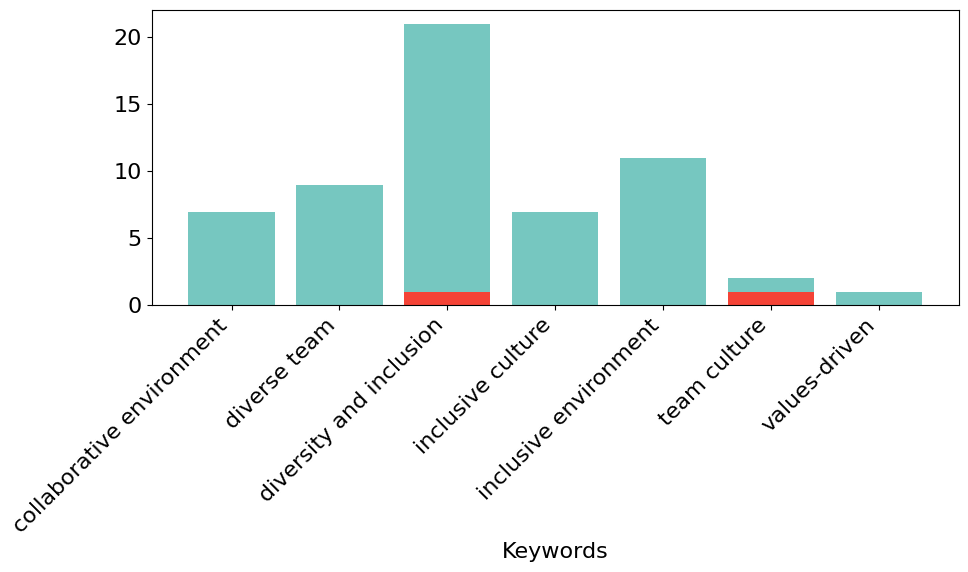

In [25]:
for benefit in benefits2:
    benefit_df = keyword_accuracy[keyword_accuracy['Benefit'] == benefit]
    plt.figure(figsize=(10, 6))
    plt.bar(benefit_df['Keywords Found'], benefit_df['total_inaccurate'], color='#F44336', label = "Inaccurate Matches")
    plt.bar(benefit_df['Keywords Found'], benefit_df['total_accurate'], color='#76C7C0', bottom=benefit_df['total_inaccurate'], label = "Accurate Matches")
    plt.xlabel('Keywords')
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.savefig(f'../figures/2_{benefit}_accuracy.png')